# Showcase Region Tile-Selection Exploration

This notebook is set up for a cleaner showcase workflow on one manually chosen region image.

The main idea is:
- use CLAM local attention to define the seed tiles
- use SAE latent similarity to expand into nearby morphologically similar tiles
- keep the expansion gate light so we cover a coherent local pattern instead of a sparse set of tiles

This notebook supports two workflows:
- run one clean showcase case with custom settings
- run a focused sweep over attention thresholds and expansion styles

The default image is the HPV+ top-right `2048x2048` showcase region we already extracted.

Note:
- the runner still saves SAE and combined importance maps for inspection
- the preset below approximates attention-first seeding by making the seed-side weighting attention-dominant, then using SAE latent similarity for growth

In [1]:
from __future__ import annotations

from pathlib import Path
import csv
import json
import shlex
import subprocess
from typing import Any

from IPython.display import Image as IPyImage, Markdown, display

WSI_CF = Path('/common/users/wq50/wsi_cf')
PACE_PY = Path('/common/users/wq50/envs/pace/bin/python')
RUNNER = WSI_CF / 'scripts/run_region_image_tile_selector.py'
EXPLORER = WSI_CF / 'scripts/run_region_image_tile_selector_exploration.py'
REGION_IMAGE = WSI_CF / 'artifacts/showcase_regions/TCGA-P3-A5QE-01Z-00-DX1_top_right_2048/region_top_right_2048.png'
NOTEBOOK_OUT = WSI_CF / 'artifacts/notebook_region_tile_selection'
NOTEBOOK_OUT.mkdir(parents=True, exist_ok=True)

print('region image:', REGION_IMAGE)
print('runner exists:', RUNNER.exists())
print('explorer exists:', EXPLORER.exists())
print('output root:', NOTEBOOK_OUT)

region image: /common/users/wq50/wsi_cf/artifacts/showcase_regions/TCGA-P3-A5QE-01Z-00-DX1_top_right_2048/region_top_right_2048.png
runner exists: True
explorer exists: True
output root: /common/users/wq50/wsi_cf/artifacts/notebook_region_tile_selection


In [2]:
def run_cmd(cmd: list[str], *, cwd: Path = WSI_CF) -> subprocess.CompletedProcess:
    print('\\n$ ' + ' '.join(shlex.quote(x) for x in cmd))
    return subprocess.run(cmd, cwd=str(cwd), check=True, text=True, capture_output=True)


def read_json(path: Path) -> dict[str, Any]:
    with path.open('r') as handle:
        return json.load(handle)


def show_case(case_dir: Path) -> None:
    meta_path = case_dir / 'region_meta.json'
    if not meta_path.exists():
        raise FileNotFoundError(meta_path)
    meta = read_json(meta_path)
    display(Markdown(f"## {case_dir.name}"))
    keys = [
        'model_backend', 'neighbor_similarity_space', 'pred', 'prob_pos',
        'attention_weight', 'sae_weight', 'attention_threshold', 'sae_threshold', 'combined_threshold',
        'high_importance_cell_count', 'seed_selected_cell_count',
        'neighbor_expanded_cell_count', 'connected_support_added_cell_count',
        'gap_fill_added_cell_count', 'selected_cell_count', 'selection_mode'
    ]
    summary = {k: meta.get(k) for k in keys if k in meta}
    display(summary)
    display(IPyImage(filename=str(case_dir / 'importance_overlay.png')))


def run_selector_case(
    case_name: str,
    *,
    attention_percentile: float = 90.0,
    sae_percentile: float = 100.0,
    combined_percentile: float = 100.0,
    sae_attention_gate_percentile: float = 100.0,
    attention_weight: float = 1.0,
    sae_weight: float = 0.0,
    target_importance_mass: float = 0.45,
    model_backend: str = 'clam',
    neighbor_similarity_space: str = 'sae',
    neighbor_similarity_threshold: float = 0.85,
    neighbor_min_combined_importance: float = 0.0,
    max_expanded_cells: int = 48,
    connected_support_min_component: int = 2,
    connected_support_min_touching_neighbors: int = 1,
    fill_gaps: bool = True,
    gap_fill_min_neighbors: int = 2,
    gap_fill_max_iters: int = 4,
    min_selected_cells: int = 6,
    max_selected_cells: int = 24,
) -> Path:
    out_dir = NOTEBOOK_OUT / case_name
    cmd = [
        str(PACE_PY), str(RUNNER),
        '--region-image', str(REGION_IMAGE),
        '--out-dir', str(out_dir),
        '--region-id', case_name,
        '--label', '1',
        '--model-backend', model_backend,
        '--grid-step-px', '256',
        '--attention-percentile', str(attention_percentile),
        '--sae-percentile', str(sae_percentile),
        '--combined-percentile', str(combined_percentile),
        '--sae-attention-gate-percentile', str(sae_attention_gate_percentile),
        '--attention-weight', str(attention_weight),
        '--sae-weight', str(sae_weight),
        '--target-importance-mass', str(target_importance_mass),
        '--neighbor-similarity-space', neighbor_similarity_space,
        '--neighbor-similarity-threshold', str(neighbor_similarity_threshold),
        '--neighbor-min-combined-importance', str(neighbor_min_combined_importance),
        '--max-expanded-cells', str(max_expanded_cells),
        '--connected-support-min-component', str(connected_support_min_component),
        '--connected-support-min-touching-neighbors', str(connected_support_min_touching_neighbors),
        '--gap-fill-min-neighbors', str(gap_fill_min_neighbors),
        '--gap-fill-max-iters', str(gap_fill_max_iters),
        '--min-selected-cells', str(min_selected_cells),
        '--max-selected-cells', str(max_selected_cells),
        '--device', 'cuda:0',
    ]
    cmd.append('--fill-gaps' if fill_gaps else '--no-fill-gaps')
    result = run_cmd(cmd)
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)
    return out_dir


def run_clean_showcase_case(
    case_name: str,
    *,
    attention_percentile: float = 90.0,
    target_importance_mass: float = 0.45,
    neighbor_similarity_threshold: float = 0.82,
    connected_support_min_component: int = 2,
    connected_support_min_touching_neighbors: int = 1,
    fill_gaps: bool = True,
    gap_fill_min_neighbors: int = 2,
    gap_fill_max_iters: int = 4,
    min_selected_cells: int = 6,
    max_selected_cells: int = 24,
) -> Path:
    return run_selector_case(
        case_name,
        attention_percentile=attention_percentile,
        sae_percentile=100.0,
        combined_percentile=100.0,
        sae_attention_gate_percentile=100.0,
        attention_weight=1.0,
        sae_weight=0.0,
        target_importance_mass=target_importance_mass,
        model_backend='clam',
        neighbor_similarity_space='sae',
        neighbor_similarity_threshold=neighbor_similarity_threshold,
        neighbor_min_combined_importance=0.0,
        max_expanded_cells=48,
        connected_support_min_component=connected_support_min_component,
        connected_support_min_touching_neighbors=connected_support_min_touching_neighbors,
        fill_gaps=fill_gaps,
        gap_fill_min_neighbors=gap_fill_min_neighbors,
        gap_fill_max_iters=gap_fill_max_iters,
        min_selected_cells=min_selected_cells,
        max_selected_cells=max_selected_cells,
    )


def run_exploration(
    sweep_name: str,
    *,
    attention_percentiles: str = '80,85,90,95',
    expansion_methods: str = 'seed_only,sae_neighbors,sae_plus_connected,full_stack_sae',
    default_neighbor_similarity_space: str = 'sae',
    neighbor_similarity_threshold: float = 0.85,
    neighbor_min_combined_importance: float = 0.0,
    target_importance_mass: float = 0.45,
    sae_percentile: float = 100.0,
    combined_percentile: float = 100.0,
    sae_attention_gate_percentile: float = 100.0,
    attention_weight: float = 1.0,
    sae_weight: float = 0.0,
) -> Path:
    out_dir = NOTEBOOK_OUT / sweep_name
    cmd = [
        str(PACE_PY), str(EXPLORER),
        '--region-image', str(REGION_IMAGE),
        '--out-dir', str(out_dir),
        '--region-id', sweep_name,
        '--label', '1',
        '--grid-step-px', '256',
        '--attention-percentiles', attention_percentiles,
        '--expansion-methods', expansion_methods,
        '--default-neighbor-similarity-space', default_neighbor_similarity_space,
        '--neighbor-similarity-threshold', str(neighbor_similarity_threshold),
        '--neighbor-min-combined-importance', str(neighbor_min_combined_importance),
        '--sae-percentile', str(sae_percentile),
        '--combined-percentile', str(combined_percentile),
        '--sae-attention-gate-percentile', str(sae_attention_gate_percentile),
        '--attention-weight', str(attention_weight),
        '--sae-weight', str(sae_weight),
        '--target-importance-mass', str(target_importance_mass),
        '--device', 'cuda:0',
    ]
    result = run_cmd(cmd)
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)
    return out_dir


def summarize_exploration(exploration_dir: Path, *, top_k: int = 10) -> list[dict[str, str]]:
    rows = list(csv.DictReader((exploration_dir / 'exploration_summary.csv').open()))
    rows = sorted(rows, key=lambda r: (-int(r['selected_cell_count']), float(r['attention_percentile']), r['expansion_method']))
    return rows[:top_k]

## Recommended Clean Showcase Run

This preset is the closest match to the cleaner selection logic we discussed:
- CLAM attention drives the seed side
- SAE latent similarity drives the first expansion stage
- the combined-importance gate is relaxed to zero during expansion
- connected support and gap fill are kept on to make the final region more coherent

You can tune the attention percentile and SAE similarity threshold first. Those two knobs are usually the most important.

\n$ /common/users/wq50/envs/pace/bin/python /common/users/wq50/wsi_cf/scripts/run_region_image_tile_selector.py --region-image /common/users/wq50/wsi_cf/artifacts/showcase_regions/TCGA-P3-A5QE-01Z-00-DX1_top_right_2048/region_top_right_2048.png --out-dir /common/users/wq50/wsi_cf/artifacts/notebook_region_tile_selection/case_clean_sae_expand_attn_seed_p90 --region-id case_clean_sae_expand_attn_seed_p90 --label 1 --model-backend clam --grid-step-px 256 --attention-percentile 90 --sae-percentile 100.0 --combined-percentile 100.0 --sae-attention-gate-percentile 100.0 --attention-weight 1.0 --sae-weight 0.0 --target-importance-mass 0.45 --neighbor-similarity-space sae --neighbor-similarity-threshold 0.82 --neighbor-min-combined-importance 0.0 --max-expanded-cells 48 --connected-support-min-component 2 --connected-support-min-touching-neighbors 1 --gap-fill-min-neighbors 2 --gap-fill-max-iters 4 --min-selected-cells 6 --max-selected-cells 24 --device cuda:0 --no-fill-gaps


## case_clean_sae_expand_attn_seed_p90

{'model_backend': 'clam',
 'neighbor_similarity_space': 'sae',
 'pred': 1,
 'prob_pos': 0.9752721190452576,
 'attention_weight': 1.0,
 'sae_weight': 0.0,
 'attention_threshold': 0.028066342696547508,
 'sae_threshold': 0.6121575236320496,
 'combined_threshold': 1.0,
 'high_importance_cell_count': 7,
 'seed_selected_cell_count': 6,
 'neighbor_expanded_cell_count': 22,
 'connected_support_added_cell_count': 0,
 'gap_fill_added_cell_count': 0,
 'selected_cell_count': 28,
 'selection_mode': 'importance_mass_plus_sae_neighbor_plus_connected_support_plus_gap_fill'}

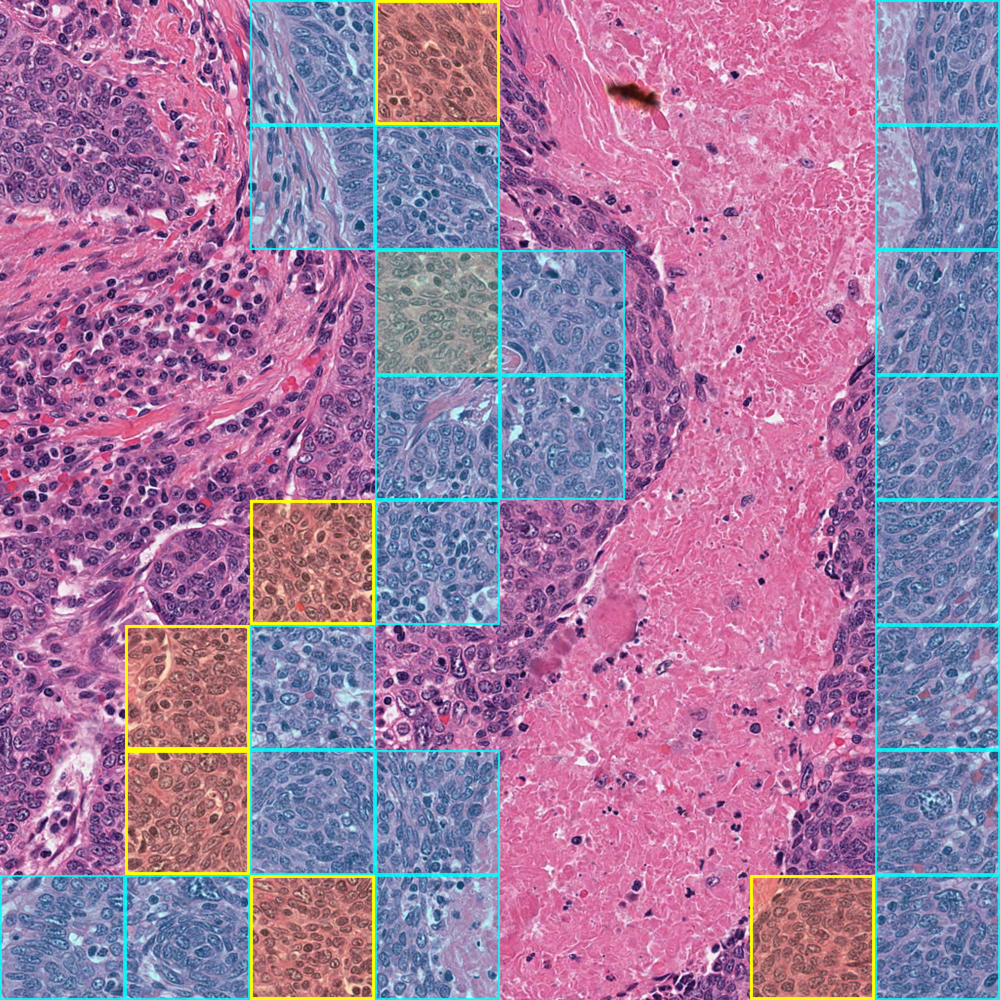

In [4]:
case_dir = run_clean_showcase_case(
    'case_clean_sae_expand_attn_seed_p90',
    attention_percentile=90,
    neighbor_similarity_threshold=0.82,
    connected_support_min_component=2,
    connected_support_min_touching_neighbors=1,
    fill_gaps=False,
    gap_fill_min_neighbors=2,
)
show_case(case_dir)

## Focused Sweep Run

This sweep stays focused on the showcase-style question:
- how much does the attention threshold change the seed footprint?
- how much extra coverage comes from SAE latent growth?
- how much do connected support and gap fill add on top of that?

The sweep below compares only the SAE-centered expansion variants.

In [12]:
exploration_dir = run_exploration(
    'showcase_clean_sae_latent_sweep',
    attention_percentiles='80,85,90,95',
    expansion_methods='seed_only,sae_neighbors,sae_plus_connected,full_stack_sae',
    default_neighbor_similarity_space='sae',
    neighbor_similarity_threshold=0.82,
    neighbor_min_combined_importance=0.0,
    sae_percentile=100.0,
    combined_percentile=100.0,
    sae_attention_gate_percentile=100.0,
    attention_weight=1.0,
    sae_weight=0.0,
    target_importance_mass=0.45,
)
exploration_dir

\n$ /common/users/wq50/envs/pace/bin/python /common/users/wq50/wsi_cf/scripts/run_region_image_tile_selector_exploration.py --region-image /common/users/wq50/wsi_cf/artifacts/showcase_regions/TCGA-P3-A5QE-01Z-00-DX1_top_right_2048/region_top_right_2048.png --out-dir /common/users/wq50/wsi_cf/artifacts/notebook_region_tile_selection/showcase_clean_sae_latent_sweep --region-id showcase_clean_sae_latent_sweep --label 1 --grid-step-px 256 --attention-percentiles 80,85,90,95 --expansion-methods seed_only,sae_neighbors,sae_plus_connected,full_stack_sae --default-neighbor-similarity-space sae --neighbor-similarity-threshold 0.82 --neighbor-min-combined-importance 0.0 --sae-percentile 100.0 --combined-percentile 100.0 --sae-attention-gate-percentile 100.0 --attention-weight 1.0 --sae-weight 0.0 --target-importance-mass 0.45 --device cuda:0


PosixPath('/common/users/wq50/wsi_cf/artifacts/notebook_region_tile_selection/showcase_clean_sae_latent_sweep')

In [13]:
top_rows = summarize_exploration(exploration_dir, top_k=12)
top_rows

[{'run_name': 'attn_p80p0__full_stack_sae',
  'attention_percentile': '80.0',
  'expansion_method': 'full_stack_sae',
  'neighbor_similarity_space': 'sae',
  'pred': '1',
  'prob_pos': '0.9752721190452576',
  'high_importance_cell_count': '13',
  'seed_selected_cell_count': '6',
  'neighbor_expanded_cell_count': '22',
  'sae_expanded_cell_count': '22',
  'connected_support_added_cell_count': '2',
  'gap_fill_added_cell_count': '22',
  'selected_cell_count': '52',
  'high_importance_cells_local': '3,0;4,0;0,1;3,1;4,1;3,2;4,3;2,4;1,5;1,6;2,7;6,7;7,7',
  'seed_selected_cells_local': '3,0;2,4;1,5;1,6;2,7;6,7',
  'selected_cells_local': '2,0;3,0;4,0;7,0;1,1;2,1;3,1;4,1;7,1;1,2;2,2;3,2;4,2;7,2;0,3;1,3;2,3;3,3;4,3;6,3;7,3;0,4;1,4;2,4;3,4;4,4;5,4;6,4;7,4;0,5;1,5;2,5;3,5;4,5;5,5;6,5;7,5;0,6;1,6;2,6;3,6;4,6;5,6;6,6;7,6;0,7;1,7;2,7;3,7;4,7;6,7;7,7',
  'overlay_path': '/common/users/wq50/wsi_cf/artifacts/notebook_region_tile_selection/showcase_clean_sae_latent_sweep/attn_p80p0__full_stack_sae/impo

### attn_p90p0__full_stack_sae

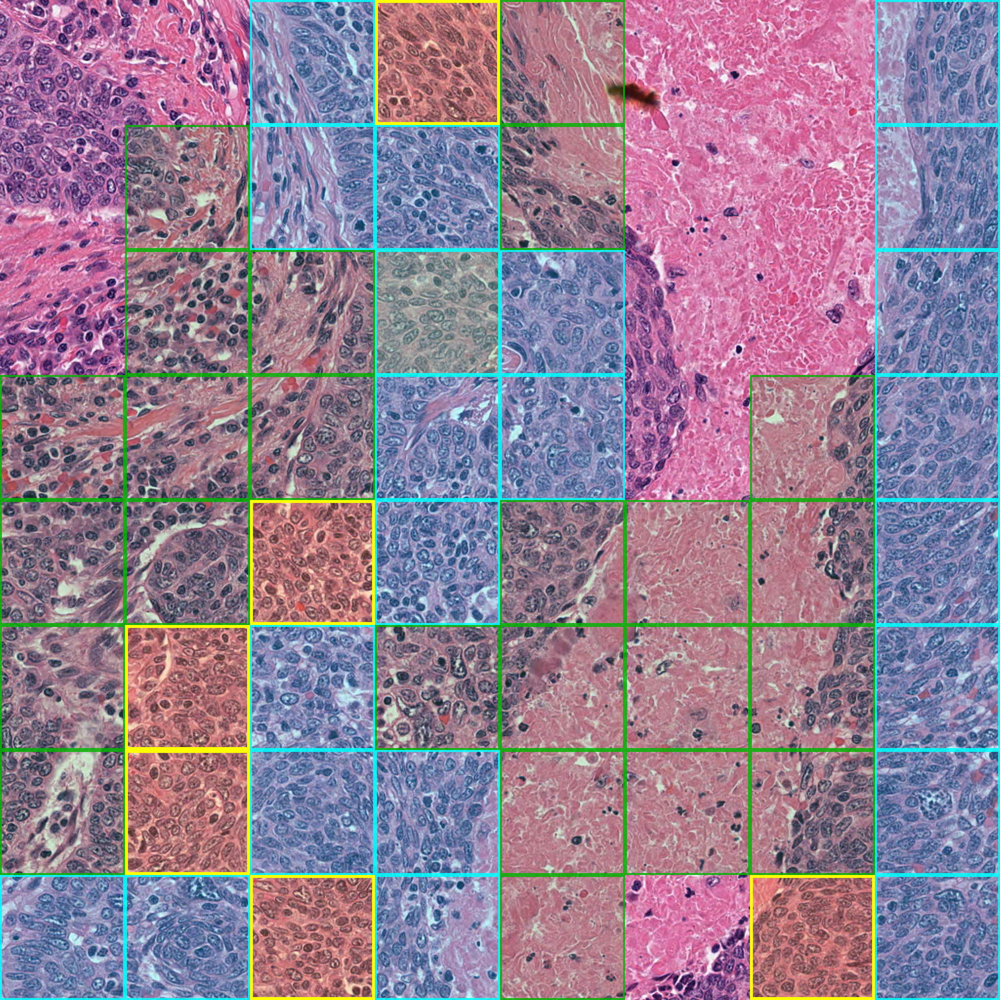

In [14]:
# Replace the run name below with any run from exploration_summary.csv
run_name = 'attn_p90p0__full_stack_sae'
overlay_path = exploration_dir / run_name / 'importance_overlay.png'
display(Markdown(f'### {run_name}'))
display(IPyImage(filename=str(overlay_path)))